# HDR Processing with Samsung Expert RAW DNG Files

This notebook applies three HDR-related workflows to Samsung S22 Expert RAW `.dng` images:

1. **True HDR using exposure stacking** from low, mid, and high exposure images.
2. **Single-image shadow boosting** using the low exposure image.
3. **Single-image highlight/shadow adjustment** using the mid exposure image.

The DNG diagnostic step has already been done separately. Based on that diagnosis, these files are loaded using `tifffile`.

Because Samsung Expert RAW DNG files are not display-ready sRGB images, this notebook uses a small approximate rendering function for visualization and for generating OpenCV-friendly 8-bit inputs.

Expected input files:

```text
images/
├── low_exposure.dng
├── mid_exposure.dng
└── high_exposure.dng
```

## 0. Requirements

Install the required packages if needed:

```bash
pip install opencv-python numpy matplotlib tifffile imagecodecs
```

## 1. Imports

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

## 2. Define Input and Output Paths

In [2]:
image_dir = Path("images")
output_dir = Path("outputs")

output_dir.mkdir(exist_ok=True)

low_exposure_path = image_dir / "low_exposure.dng"
mid_exposure_path = image_dir / "mid_exposure.dng"
high_exposure_path = image_dir / "high_exposure.dng"

# Method 2 uses the low exposure image as the underexposed input.
underexposed_path = low_exposure_path

image_paths = [
    low_exposure_path,
    mid_exposure_path,
    high_exposure_path,
]

for path in image_paths:
    print(path, "exists:", path.exists())

images/low_exposure.dng exists: True
images/mid_exposure.dng exists: True
images/high_exposure.dng exists: True


## 3. Rendering and Display Utilities

`tifffile` can read the image data from the Samsung Expert RAW DNG files, but the returned array is not necessarily display-ready sRGB.

If we display the raw array directly, the image may look too dark or have strange color casts. Therefore, this notebook uses an approximate rendering function that applies:

```text
robust percentile normalization
gray-world white balance approximation
gamma correction
```

This is not a full RAW development pipeline, but it makes the images visually usable for this OpenCV HDR demonstration.

In [3]:
def read_dng_array(image_path):
    """
    Read a Samsung Expert RAW / Linear DNG file using tifffile.

    Returns:
        NumPy array directly from the DNG/TIFF container.
    """
    img = tiff.imread(str(image_path))
    img = np.asarray(img)
    img = np.squeeze(img)
    return img


def prepare_array_shape(img):
    """
    Prepare an image array for display/processing.

    Handles:
    - channel-first to channel-last
    - alpha removal
    - grayscale to 3-channel
    """
    img = np.asarray(img)
    img = np.squeeze(img)

    # If channel-first, move channels to the end.
    # Example: (3, H, W) -> (H, W, 3)
    if img.ndim == 3 and img.shape[0] in [3, 4] and img.shape[-1] not in [3, 4]:
        img = np.moveaxis(img, 0, -1)

    # Remove alpha channel if present.
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]

    # If single-channel, make it 3-channel.
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    # Rotate clockwise by 90 degrees.
    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    return img


def render_for_display(
    img,
    black_percentile=0.1,
    white_percentile=99.8,
    gamma=1 / 2.2,
    apply_gray_world_wb=True
):
    """
    Approximate display rendering for Linear DNG / camera-space image arrays.

    This is for visualization and OpenCV-friendly demonstration inputs.
    It is not a complete RAW development pipeline.
    """

    if img is None:
        return None

    img = prepare_array_shape(img)
    img_float = img.astype(np.float32)

    # Robust normalization instead of min/max.
    # Min/max can be dominated by hot pixels or a few saturated pixels.
    black = np.percentile(img_float, black_percentile)
    white = np.percentile(img_float, white_percentile)

    img_float = (img_float - black) / max(white - black, 1e-8)
    img_float = np.clip(img_float, 0.0, 1.0)

    # Approximate gray-world white balance.
    if apply_gray_world_wb and img_float.ndim == 3 and img_float.shape[-1] == 3:
        channel_means = img_float.reshape(-1, 3).mean(axis=0)
        gray_mean = channel_means.mean()
        gains = gray_mean / np.maximum(channel_means, 1e-8)

        img_float = img_float * gains.reshape(1, 1, 3)
        img_float = np.clip(img_float, 0.0, 1.0)

    # Gamma correction for normal display.
    img_float = np.power(img_float, gamma)
    img_float = np.clip(img_float, 0.0, 1.0)

    img_8bit_rgb = (img_float * 255).astype(np.uint8)

    return img_8bit_rgb


def load_dng_rendered_rgb_8bit(image_path):
    """
    Load a DNG and return an approximately rendered 8-bit RGB image.
    """
    img = read_dng_array(image_path)
    return render_for_display(img)


def load_dng_rendered_bgr_8bit(image_path):
    """
    Load a DNG and return an approximately rendered 8-bit BGR image for OpenCV.
    """
    rgb = load_dng_rendered_rgb_8bit(image_path)
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    return bgr


def load_dng_rendered_bgr_float(image_path):
    """
    Load a DNG and return an approximately rendered float32 BGR image in [0, 1].
    """
    bgr_8bit = load_dng_rendered_bgr_8bit(image_path)
    bgr_float = bgr_8bit.astype(np.float32) / 255.0
    return bgr_float


def bgr_to_rgb_for_display(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def float_bgr_to_rgb_for_display(img_bgr_float):
    img_bgr_8bit = np.clip(img_bgr_float * 255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(img_bgr_8bit, cv2.COLOR_BGR2RGB)


def save_float_image_as_8bit(img_float, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    img_8bit = np.clip(img_float * 255, 0, 255).astype(np.uint8)

    success = cv2.imwrite(str(output_path), img_8bit)

    if not success:
        raise IOError(f"Could not save image: {output_path}")

    return img_8bit

# Method 1: True HDR by Exposure Stacking

This method uses all three exposures together:

```text
low exposure  → preserves highlights
mid exposure  → preserves midtones
high exposure → reveals shadows
```

The DNG files are first approximately rendered into 8-bit OpenCV BGR images. Then OpenCV is used for alignment, camera response estimation, HDR merging, and tone mapping.

Note: because the Samsung Expert RAW DNGs require approximate rendering before OpenCV can comfortably process them, this is best understood as an OpenCV HDR demonstration pipeline rather than a physically perfect RAW HDR pipeline.

## 4. Load Bracketed Exposures

In [4]:
images = [load_dng_rendered_bgr_8bit(path) for path in image_paths]

# Important:
# Replace these with the actual shutter/exposure times from your camera metadata.
# The order must match image_paths: low, mid, high.
exposure_times = np.array([
    1 / 500,  # low exposure
    1 / 90,   # mid exposure
    1 / 50,   # high exposure
], dtype=np.float32)

print(f"Loaded {len(images)} images.")
for path, img, exposure in zip(image_paths, images, exposure_times):
    print(f"{path.name}: shape={img.shape}, dtype={img.dtype}, exposure={exposure:.6f} s")

Loaded 3 images.
low_exposure.dng: shape=(4080, 3060, 3), dtype=uint8, exposure=0.002000 s
mid_exposure.dng: shape=(4080, 3060, 3), dtype=uint8, exposure=0.011111 s
high_exposure.dng: shape=(4080, 3060, 3), dtype=uint8, exposure=0.020000 s


## 5. Display the Input Exposure Bracket

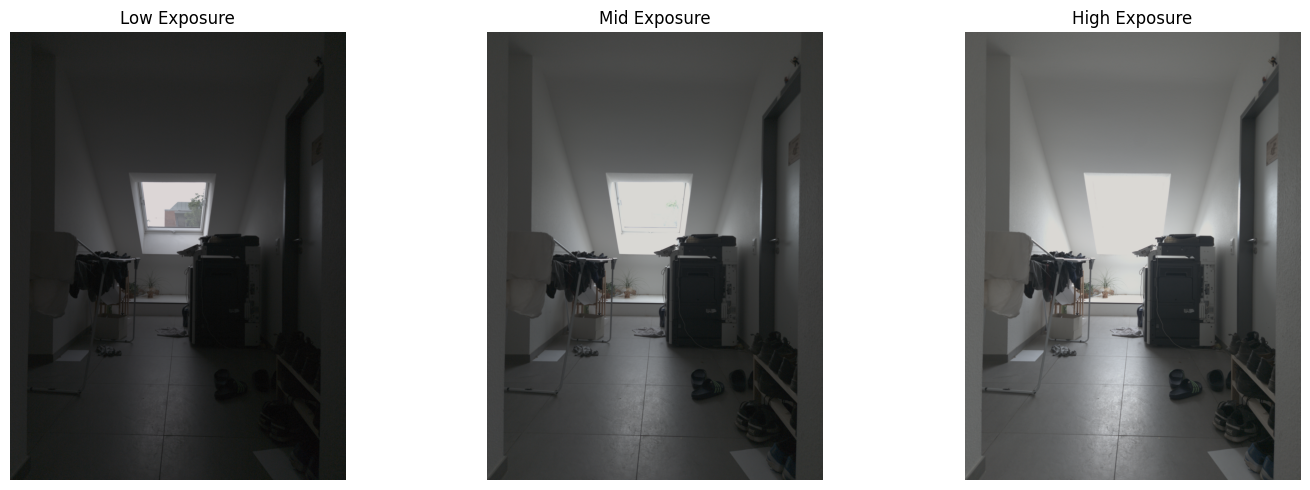

In [5]:
titles = [
    "Low Exposure",
    "Mid Exposure",
    "High Exposure",
]

plt.figure(figsize=(15, 5))

for i, img in enumerate(images):
    plt.subplot(1, 3, i + 1)
    plt.imshow(bgr_to_rgb_for_display(img))
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Align the Exposures

In [6]:
aligned_images = [img.copy() for img in images]

align = cv2.createAlignMTB()
align.process(aligned_images, aligned_images)

print("Alignment complete.")

Alignment complete.


## 7. Estimate the Camera Response Function

In [7]:
calibrate = cv2.createCalibrateDebevec()
response = calibrate.process(aligned_images, exposure_times)

print("Camera response estimated.")
print("Response shape:", response.shape)

Camera response estimated.
Response shape: (256, 1, 3)


## 8. Merge Exposures into an HDR Radiance Map

In [8]:
merge_debevec = cv2.createMergeDebevec()
hdr = merge_debevec.process(aligned_images, exposure_times, response)

hdr_output_path = output_dir / "method_1_stacked_hdr.hdr"
success = cv2.imwrite(str(hdr_output_path), hdr)

if not success:
    raise IOError(f"Could not save HDR file: {hdr_output_path}")

print("HDR saved to:", hdr_output_path)
print("HDR shape:", hdr.shape)
print("HDR dtype:", hdr.dtype)
print("HDR min/max:", np.nanmin(hdr), np.nanmax(hdr))

HDR saved to: outputs/method_1_stacked_hdr.hdr
HDR shape: (4080, 3060, 3)
HDR dtype: float32
HDR min/max: 0.078706026 775.39264


## 9. Tone-Map the HDR Result for Display

[ WARN:0@24.262] global matrix_expressions.cpp:1333 assign OpenCV/MatExpr: processing of multi-channel arrays might be changed in the future: https://github.com/opencv/opencv/issues/16739


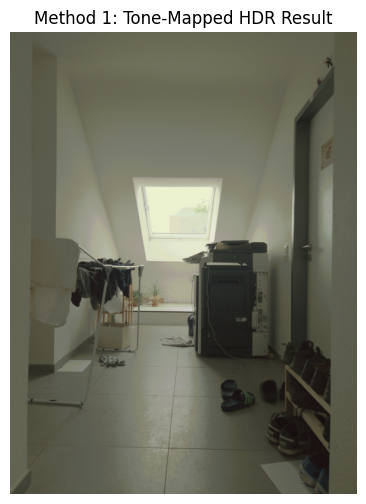

Tone-mapped result saved to: outputs/method_1_stacked_hdr_tonemapped.jpg


In [9]:
tonemap = cv2.createTonemapReinhard(
    gamma=1.5,
    intensity=0.0,
    light_adapt=0.8,
    color_adapt=0.0
)

ldr = tonemap.process(hdr)

# Tone mapping can sometimes create NaN/Inf values depending on the input.
ldr = np.nan_to_num(ldr, nan=0.0, posinf=1.0, neginf=0.0)

ldr_8bit = np.clip(ldr * 255, 0, 255).astype(np.uint8)

tonemapped_output_path = output_dir / "method_1_stacked_hdr_tonemapped.jpg"
success = cv2.imwrite(str(tonemapped_output_path), ldr_8bit)

if not success:
    raise IOError(f"Could not save tone-mapped image: {tonemapped_output_path}")

plt.figure(figsize=(8, 6))
plt.imshow(bgr_to_rgb_for_display(ldr_8bit))
plt.title("Method 1: Tone-Mapped HDR Result")
plt.axis("off")
plt.show()

print("Tone-mapped result saved to:", tonemapped_output_path)

# Method 2: Boost Shadows in the Low Exposure Image

This method uses only the low exposure image.

It is **not true HDR** because it does not merge multiple exposures. It starts from an underexposed image that preserves highlights, then digitally lifts shadows and improves local contrast.

## 10. Load the Low Exposure as a Float Image

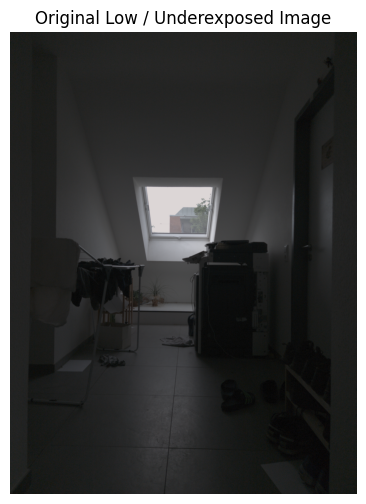

Underexposed input: images/low_exposure.dng
Shape: (4080, 3060, 3)
Dtype: float32
Min/max: 0.0 0.87058824


In [10]:
under_img = load_dng_rendered_bgr_float(underexposed_path)

plt.figure(figsize=(8, 6))
plt.imshow(float_bgr_to_rgb_for_display(under_img))
plt.title("Original Low / Underexposed Image")
plt.axis("off")
plt.show()

print("Underexposed input:", underexposed_path)
print("Shape:", under_img.shape)
print("Dtype:", under_img.dtype)
print("Min/max:", under_img.min(), under_img.max())

## 11. Apply Gamma Correction to Lift Shadows

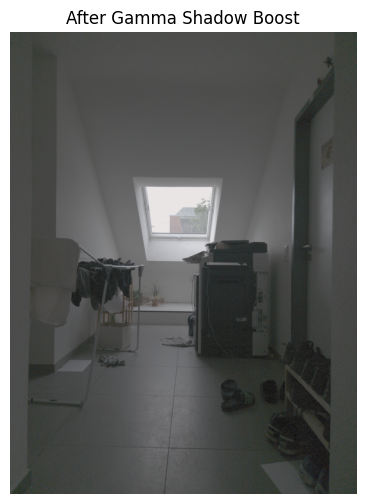

In [11]:
def gamma_correct(img_float, gamma=0.6):
    corrected = np.power(np.clip(img_float, 0.0, 1.0), gamma)
    return np.clip(corrected, 0.0, 1.0)


shadow_boosted = gamma_correct(under_img, gamma=0.6)

plt.figure(figsize=(8, 6))
plt.imshow(float_bgr_to_rgb_for_display(shadow_boosted))
plt.title("After Gamma Shadow Boost")
plt.axis("off")
plt.show()

## 12. Apply CLAHE for Local Contrast

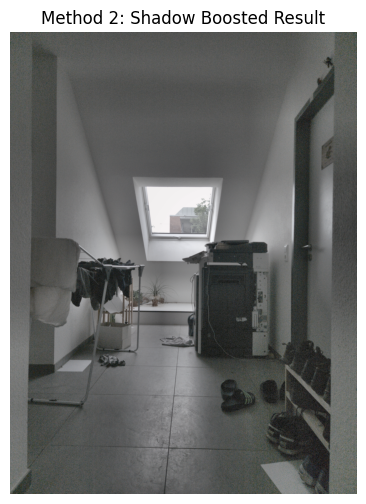

Method 2 saved to: outputs/method_2_shadow_boosted.jpg


In [12]:
def apply_clahe_to_float_bgr(img_float, clip_limit=2.0, tile_grid_size=(8, 8)):
    img_8bit = np.clip(img_float * 255, 0, 255).astype(np.uint8)

    lab = cv2.cvtColor(img_8bit, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    l_enhanced = clahe.apply(l)

    lab_enhanced = cv2.merge([l_enhanced, a, b])
    result = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)

    return result.astype(np.float32) / 255.0


method_2_result = apply_clahe_to_float_bgr(shadow_boosted)

method_2_output_path = output_dir / "method_2_shadow_boosted.jpg"
save_float_image_as_8bit(method_2_result, method_2_output_path)

plt.figure(figsize=(8, 6))
plt.imshow(float_bgr_to_rgb_for_display(method_2_result))
plt.title("Method 2: Shadow Boosted Result")
plt.axis("off")
plt.show()

print("Method 2 saved to:", method_2_output_path)

# Method 3: Reduce Highlights and Boost Shadows in the Mid Exposure Image

This method uses only the mid exposure image.

It is also **not true HDR**. It is a single-image tone adjustment method that reduces highlights, lifts shadows, and improves local contrast.

## 13. Load the Mid Exposure as a Float Image

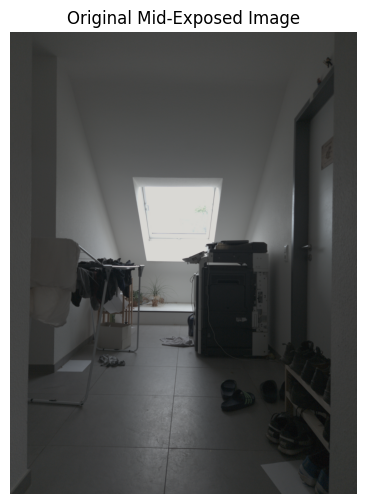

Mid exposure input: images/mid_exposure.dng
Shape: (4080, 3060, 3)
Dtype: float32
Min/max: 0.0 0.8627451


In [13]:
mid_img = load_dng_rendered_bgr_float(mid_exposure_path)

plt.figure(figsize=(8, 6))
plt.imshow(float_bgr_to_rgb_for_display(mid_img))
plt.title("Original Mid-Exposed Image")
plt.axis("off")
plt.show()

print("Mid exposure input:", mid_exposure_path)
print("Shape:", mid_img.shape)
print("Dtype:", mid_img.dtype)
print("Min/max:", mid_img.min(), mid_img.max())

## 14. Apply Highlight and Shadow Adjustment

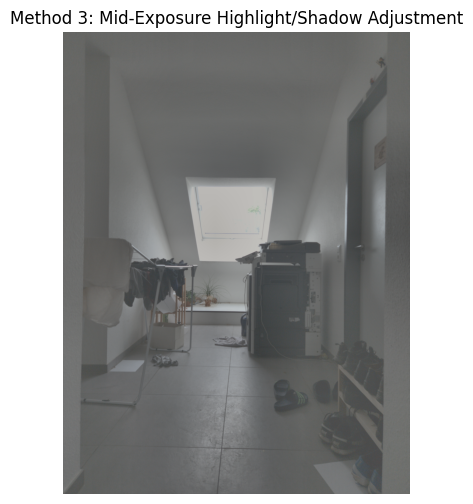

Method 3 saved to: outputs/method_3_mid_exposure_adjusted.jpg


In [14]:
def adjust_highlights_and_shadows(
    img_float,
    shadow_boost=0.35,
    highlight_reduction=0.25,
    clahe_clip_limit=2.0,
    clahe_tile_grid_size=(8, 8)
):
    img_8bit = np.clip(img_float * 255, 0, 255).astype(np.uint8)

    lab = cv2.cvtColor(img_8bit, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    l_float = l.astype(np.float32) / 255.0

    # Stronger in dark regions.
    shadow_mask = 1.0 - l_float

    # Stronger in bright regions.
    highlight_mask = l_float

    adjusted_l = l_float.copy()

    # Lift shadows.
    adjusted_l = adjusted_l + shadow_boost * shadow_mask * (1.0 - adjusted_l)

    # Pull down highlights.
    adjusted_l = adjusted_l - highlight_reduction * highlight_mask * adjusted_l

    adjusted_l = np.clip(adjusted_l, 0.0, 1.0)

    adjusted_l_8bit = np.clip(adjusted_l * 255, 0, 255).astype(np.uint8)

    # Improve local contrast after global tonal adjustment.
    clahe = cv2.createCLAHE(
        clipLimit=clahe_clip_limit,
        tileGridSize=clahe_tile_grid_size
    )

    adjusted_l_8bit = clahe.apply(adjusted_l_8bit)

    lab_adjusted = cv2.merge([adjusted_l_8bit, a, b])
    result = cv2.cvtColor(lab_adjusted, cv2.COLOR_LAB2BGR)

    return result.astype(np.float32) / 255.0


method_3_result = adjust_highlights_and_shadows(
    mid_img,
    shadow_boost=0.35,
    highlight_reduction=0.25
)

method_3_output_path = output_dir / "method_3_mid_exposure_adjusted.jpg"
save_float_image_as_8bit(method_3_result, method_3_output_path)

plt.figure(figsize=(8, 6))
plt.imshow(float_bgr_to_rgb_for_display(method_3_result))
plt.title("Method 3: Mid-Exposure Highlight/Shadow Adjustment")
plt.axis("off")
plt.show()

print("Method 3 saved to:", method_3_output_path)

# Method Comparison

## 15. Visual Comparison

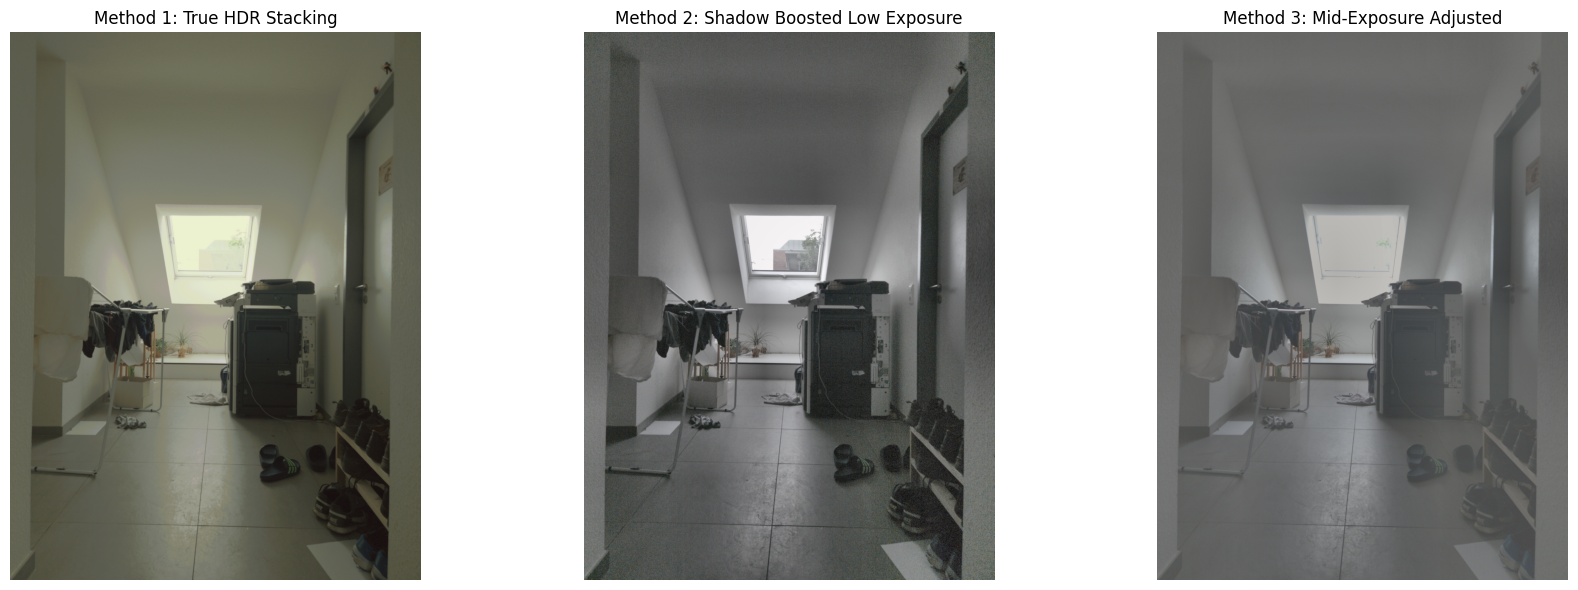

In [15]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(bgr_to_rgb_for_display(ldr_8bit))
plt.title("Method 1: True HDR Stacking")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(float_bgr_to_rgb_for_display(method_2_result))
plt.title("Method 2: Shadow Boosted Low Exposure")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(float_bgr_to_rgb_for_display(method_3_result))
plt.title("Method 3: Mid-Exposure Adjusted")
plt.axis("off")

plt.tight_layout()
plt.show()

## 16. Save Comparison Figure

In [ ]:
# Save the three input images as a reference figure.
input_reference_output_path = output_dir / "input_exposure_reference.jpg"

fig = plt.figure(figsize=(18, 6))

for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(bgr_to_rgb_for_display(img))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.savefig(input_reference_output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Input exposure reference saved to:", input_reference_output_path)


# Save the three method outputs using the same 1x3 layout.
output_comparison_path = output_dir / "method_output_comparison.jpg"

fig = plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(bgr_to_rgb_for_display(ldr_8bit))
plt.title("Method 1: True HDR Stacking")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(float_bgr_to_rgb_for_display(method_2_result))
plt.title("Method 2: Shadow Boosted")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(float_bgr_to_rgb_for_display(method_3_result))
plt.title("Method 3: Mid-Exposure Adjusted")
plt.axis("off")

plt.tight_layout()
plt.savefig(output_comparison_path, dpi=300, bbox_inches="tight")
plt.show()

print("Method output comparison saved to:", output_comparison_path)


# Optional: Save one combined figure with inputs on the first row and outputs on the second row.
combined_comparison_path = output_dir / "input_and_output_comparison.jpg"

fig = plt.figure(figsize=(18, 12))

# Row 1: input exposures
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(bgr_to_rgb_for_display(img))
    plt.title(f"Input: {title}")
    plt.axis("off")

# Row 2: method outputs
plt.subplot(2, 3, 4)
plt.imshow(bgr_to_rgb_for_display(ldr_8bit))
plt.title("Output: Method 1 HDR Stacking")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(float_bgr_to_rgb_for_display(method_2_result))
plt.title("Output: Method 2 Shadow Boosted")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(float_bgr_to_rgb_for_display(method_3_result))
plt.title("Output: Method 3 Mid-Exposure Adjusted")
plt.axis("off")

plt.tight_layout()
plt.savefig(combined_comparison_path, dpi=300, bbox_inches="tight")
plt.show()

print("Combined input/output comparison saved to:", combined_comparison_path)

# Notes

- Method 1 is the only true HDR method in this notebook because it combines multiple exposure captures.
- Method 2 is single-image shadow recovery from the low/underexposed image.
- Method 3 is single-image tone adjustment from the mid-exposed image.
- The exposure times in Method 1 must be replaced with the real shutter speeds from your camera metadata.
- If the HDR result looks wrong, first check whether the exposure times match the image order.
- The DNG rendering function is an approximate visualization/rendering step, not a complete RAW development pipeline.
- For a more production-grade workflow, export the Samsung Expert RAW files as 16-bit TIFFs from a RAW-aware application, then process the TIFFs in OpenCV.